## Imports

In [1]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from pybeamline.mappers.print_operator import print_operator
from pybeamline.sources import BEvent
from river.tree import HoeffdingAdaptiveTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

from models.darwin import DARWINClassifier, DARWINRegressor
from utils.experiment import load_config
from utils.streaming.base.bucketers import PrefixLengthBucketer
from utils.streaming.base.drift_detectors import NoDriftDetector
from utils.streaming.base.emitters import (
    NextActivityEmitter,
    OutcomeEmitter,
    RemainingTimeEmitter,
)
from utils.streaming.base.extractors import BinaryOutcomeExtractor
from utils.streaming.base.learners import (
    NextActivityLearner,
    OutcomeLearner,
    RemainingTimeLearner,
)
from utils.streaming.base.maps import EmptyMap
from utils.streaming.base.pipelines import (
    BEventSource,
    PipelineMode,
    SourceMode,
    TaskPipeline,
)
from utils.streaming.base.predictors import PredictorMap
from utils.streaming.base.sinks import (
    EmptySink,
    NextActivityEvaluator,
    OutcomeEvaluator,
    RemainingTimeEvaluator,
)
from utils.streaming.base.transformers import DARWINTransformer, IndexBasedTransformer
from utils.streaming.time import TimeTarget

## Next Activity Pipeline

In [2]:
class TestPipeline(TaskPipeline):
    def __init__(self, model, transformer, end_events, predict_only=False):
        super().__init__(
            model=model,
            transformer=transformer,
            end_events=end_events,
            pipeline_mode=PipelineMode.PREDICT_AND_LEARN,
            source_mode=SourceMode.BEVENTS,
        )
        self.predict_only = predict_only

    def get_emitter(self):
        return NextActivityEmitter(self.transformer, end_events=self.end_events)

    def get_predictor(self):
        return PredictorMap(self.model)

    def get_learner(self):
        return NextActivityLearner(self.model)

    def get_sink(self):
        return NextActivityEvaluator()
        return EmptySink()

    def run(self, bevents: list[BEvent]):
        source_obj = BEventSource()
        source = source_obj.get_source(bevents=bevents)

        emitter = self.get_emitter()
        predictor = self.get_predictor()
        learner = self.get_learner()
        sink = self.get_sink()

        source.pipe(
            emitter,
            # print_operator(
            #     'EMIT> trace_id={0[0]}, features={0[1]}, y_true={0[2]}'
            # ),
            predictor,
            print_operator(
                'PREDICT> trace_id={0[0]}, features={0[1]}, y_true={0[2]}, y_pred={0[3]}'
            )
            if self.predict_only
            else EmptyMap(),
            learner if not self.predict_only else EmptyMap(),
        ).sink(sink)

        df = sink.to_dataframe()

        return df, self.model

## Next activity predictions

In [3]:
EVENTS = [
    ('ABCDEF', 1000),
    # ('GHIJKL', 1000),
]

unique_events = {event for trace, count in EVENTS for event in trace}
end_events = {event for trace, count in EVENTS for event in trace[-1]}

print(f'Unique events: {unique_events}')
print(f'End events: {end_events}')

bevents = []
_case_id = 0
for i, (trace, count) in enumerate(EVENTS):
    for j in range(count):
        _case_id += 1
        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process'))

Unique events: {'A', 'B', 'E', 'F', 'C', 'D'}
End events: {'F'}


In [4]:
model = HoeffdingAdaptiveTreeClassifier(
    drift_detector=NoDriftDetector(),
    grace_period=100,
    delta=0.001,
    tau=0.05,
    split_criterion='info_gain',
    leaf_prediction='nba',
    nb_threshold=10,
    max_depth=20,
    seed=42,
)

transformer = IndexBasedTransformer(
    max_events=6,
    include_prefix_len=False
)

pipeline = TestPipeline(
    model=model, transformer=transformer, end_events=end_events
)
results_df, model = pipeline.run(bevents)

In [5]:
darwin_model = DARWINClassifier(
    embedding_dim=4,
    w2v_window=5,
    sequence_window=4,
    optimizer_cls=lambda p: optim.NAdam(p, lr=0.1),
    loss_fn=nn.CrossEntropyLoss(),
    lstm_layers=1,
    hidden_dim=32,
    dropout=0.01,
    batch_size=32,
    dynamic_n_classes=True,
    n_classes=len(unique_events),
    max_n_classes=20,
    drift_detector=NoDriftDetector(),
    epochs=10,
    # early_stop_patience=5,
    init_size=int(len(bevents) * 0.1),
    end_events=end_events,
)

darwin_transformer = DARWINTransformer()

pipeline = TestPipeline(
    model=darwin_model, transformer=darwin_transformer, end_events=end_events
)
darwin_results_df, darwin_model = pipeline.run(bevents)

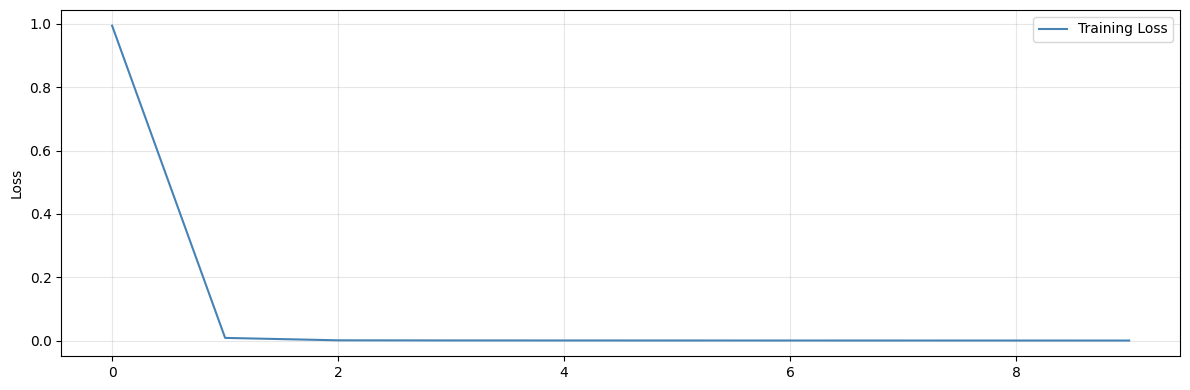

In [6]:
if hasattr(darwin_model, 'loss_history'):
    _, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        darwin_model.loss_history,
        label='Training Loss',
        color='steelblue',
        linewidth=1.5,
    )
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')
    ax.set_ylabel('Loss')
    ax.legend(loc='best')

    plt.tight_layout()

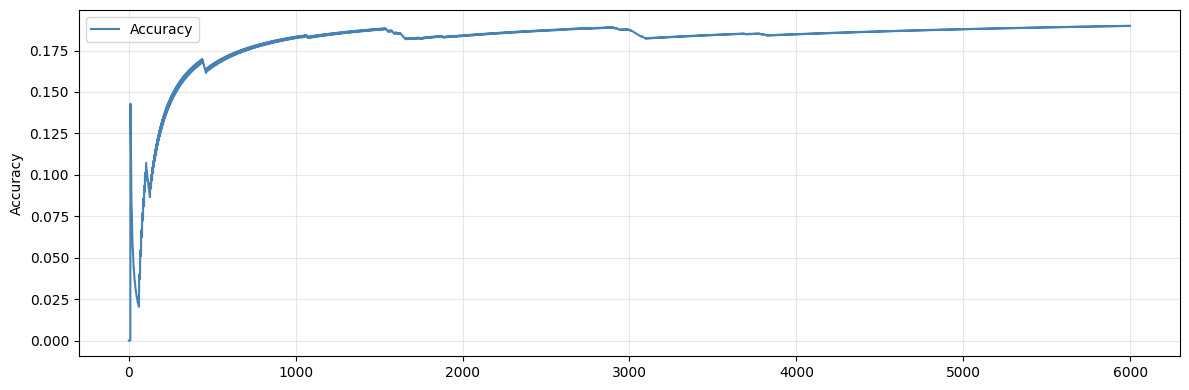

In [7]:
_, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    results_df['accuracy'],
    label='Accuracy',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
ax.legend(loc='best')
plt.tight_layout()

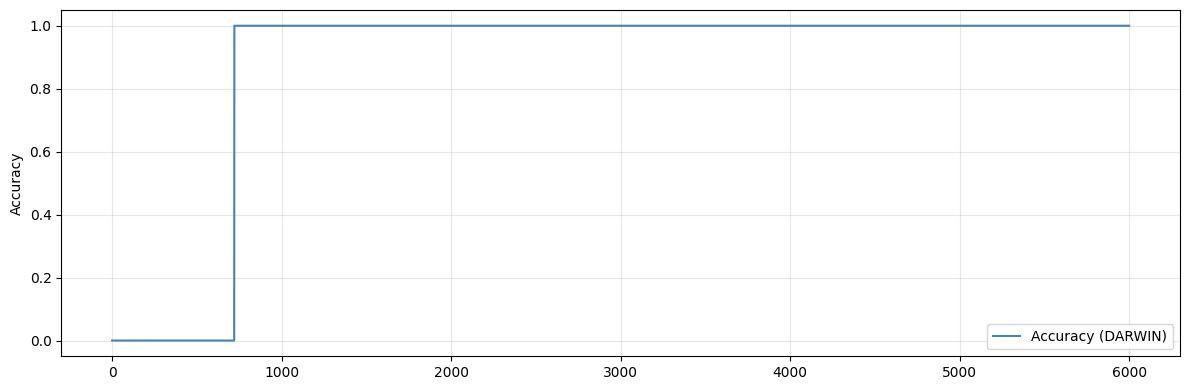

In [8]:
_, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    darwin_results_df['accuracy'],
    label='Accuracy (DARWIN)',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
ax.legend(loc='best')
plt.tight_layout()

In [9]:
results_df.tail()

,trace_id,y_true,y_pred,n_pred,n_drifts,drift_detected,trace_n,prefix_len,loss,accuracy,macro_f1
5995,1000,B,D,4994,0,False,1000,2,None,0.189828,0.146329
5996,1000,C,D,4995,0,False,1000,3,None,0.189790,0.146300
5997,1000,D,D,4996,0,False,1000,4,None,0.189952,0.146375
5998,1000,E,D,4997,0,False,1000,5,None,0.189914,0.146341
5999,1000,F,D,4998,0,False,1000,6,None,0.189876,0.146326


In [10]:
darwin_results_df.tail()

,trace_id,y_true,y_pred,n_pred,n_drifts,drift_detected,trace_n,prefix_len,loss,accuracy,macro_f1
5995,1000,B,B,4396,0,False,1000,2,0.000134,1.0,1.0
5996,1000,C,C,4397,0,False,1000,3,0.000134,1.0,1.0
5997,1000,D,D,4398,0,False,1000,4,0.000134,1.0,1.0
5998,1000,E,E,4399,0,False,1000,5,0.000134,1.0,1.0
5999,1000,F,F,4400,0,False,1000,6,0.000134,1.0,1.0


In [11]:
predict_bevents = [BEvent(event, 'unseen', 'Test process') for event in 'ABCDEF']

predict_pipeline = TestPipeline(
    model=model,
    transformer=transformer,
    end_events=end_events,
    predict_only=True,
)
predict_results_df, _ = predict_pipeline.run(predict_bevents)

PREDICT> trace_id=unseen, features={'act_0': 'A'}, y_true=A, y_pred=D
PREDICT> trace_id=unseen, features={'act_0': 'B', 'act_1': 'A'}, y_true=B, y_pred=D
PREDICT> trace_id=unseen, features={'act_0': 'C', 'act_1': 'B', 'act_2': 'A'}, y_true=C, y_pred=D
PREDICT> trace_id=unseen, features={'act_0': 'D', 'act_1': 'C', 'act_2': 'B', 'act_3': 'A'}, y_true=D, y_pred=D
PREDICT> trace_id=unseen, features={'act_0': 'E', 'act_1': 'D', 'act_2': 'C', 'act_3': 'B', 'act_4': 'A'}, y_true=E, y_pred=D
PREDICT> trace_id=unseen, features={}, y_true=F, y_pred=None


In [12]:
darwin_predict_pipeline = TestPipeline(
    model=darwin_model,
    transformer=darwin_transformer,
    end_events=end_events,
    predict_only=True,
)
darwin_predict_results_df, _ = darwin_predict_pipeline.run(predict_bevents)

PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'A', 'event_id': 6001}, y_true=A, y_pred=B
PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'B', 'event_id': 6002}, y_true=B, y_pred=C
PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'C', 'event_id': 6003}, y_true=C, y_pred=D
PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'D', 'event_id': 6004}, y_true=D, y_pred=E
PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'E', 'event_id': 6005}, y_true=E, y_pred=F
PREDICT> trace_id=unseen, features={}, y_true=F, y_pred=None


## Plots

In [ ]:
_, ax = plt.subplots(figsize=(12, 4))

plot_df = (
    results_df.dropna(subset=['y_pred'])
    .sort_values('n_pred')
    .reset_index(drop=True)
    .copy()
)

ax.plot(
    plot_df['macro_f1'],
    label='Macro F1-score',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
ax.set_title('Macro F1-score over stream predictions')
ax.set_xlabel('Prediction #')
ax.legend(loc='best')

In [ ]:
_, ax = plt.subplots(figsize=(12, 4))

grouped_df = (
    plot_df.groupby('trace_id')
    .agg({'macro_f1': 'mean'})
    .sort_values('trace_id')
    .reset_index()
    .copy()
)

ax.plot(
    grouped_df['macro_f1'],
    label='Macro F1-score',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
ax.set_title('Macro F1-score averaged over traces')
ax.set_xlabel('Trace #')
ax.legend(loc='best')

In [ ]:
_, ax = plt.subplots(figsize=(12, 4))

window_size = 100
center_window = True
metric = 'f1'
# metric = 'accuracy'


def get_windowed_metric(
    df,
    window_size,
    center_window,
    metric='f1',
    group_by=None,
    agg='mean',
    **metric_kwargs,
):
    y_true = np.asarray(df['y_true'])
    y_pred = np.asarray(df['y_pred'])

    metric_map = {
        'f1': lambda yt, yp: f1_score(
            yt, yp, average='macro', zero_division=0, **metric_kwargs
        ),
        'accuracy': lambda yt, yp: accuracy_score(yt, yp, **metric_kwargs),
    }
    metric_fn = metric_map[metric]

    n = len(y_true)
    scores = np.empty(n, dtype=float)

    if center_window:
        left = window_size // 2
        right = window_size - left
        for i in range(n):
            start = max(0, i - left)
            end = min(n, i + right)
            scores[i] = metric_fn(y_true[start:end], y_pred[start:end])
    else:
        for i in range(n):
            start = max(0, i - window_size + 1)
            end = i + 1
            scores[i] = metric_fn(y_true[start:end], y_pred[start:end])

    if group_by is None:
        return scores

    out = df.copy()
    metric_col = f'windowed_{metric}'
    out[metric_col] = scores

    grouped = out.groupby(group_by, dropna=False)[metric_col].agg(agg).reset_index()

    return grouped[metric_col].values


windowed_df = plot_df.sort_values(['trace_n', 'n_pred']).reset_index(drop=True).copy()

metric_values = get_windowed_metric(
    windowed_df,
    window_size=window_size,
    center_window=center_window,
    metric=metric,
)

ax.plot(
    metric_values,
    label=f'{metric.capitalize()}',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
ax.set_title(
    f'{metric.capitalize()} windowed (window={window_size}, center={center_window})'
)
ax.set_xlabel('Prediction #')
ax.legend(loc='best')

In [ ]:
_, ax = plt.subplots(figsize=(12, 4))

trace_metric_values = get_windowed_metric(
    windowed_df,
    window_size=window_size,
    center_window=center_window,
    metric=metric,
    group_by='trace_id',
    agg='mean',
)

ax.plot(
    trace_metric_values,
    label=f'{metric.capitalize()}',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
ax.set_title(
    f'{metric.capitalize()} windowed (window={window_size}, center={center_window}) averaged over traces'
)
ax.set_xlabel('Trace #')
ax.legend(loc='best')

## Hyperparameter optimization

In [2]:
from utils.streaming.hyperparam import (
    extract_trial_rows,
    run_hyperopt,
    save_cfg_yaml,
    save_top_models,
)

c:\Users\Pavel\Desktop\PROJECTS\master-thesis\.venv\lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
darwin_config_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/conf/experiments/streaming/next_activity/baseline/darwin/BPIC_20_DD_hypersearch.yaml'

search_name = 'debug_notebook_hypersearch'
top_k = 10

report_dir = f'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/hypersearch/{search_name}'

In [4]:
cfg = load_config(str(darwin_config_path))
hyperopt_results = run_hyperopt(cfg)
trial_rows = extract_trial_rows(hyperopt_results)

metric_name = hyperopt_results['metric']
maximize = hyperopt_results['maximize']
print(f'metric={metric_name}, maximize={maximize}, trials={len(trial_rows)}')

if trial_rows:
    best_model_cfg = trial_rows[0]['model_cfg']
    best_transformer_cfg = trial_rows[0]['transformer_cfg']

    debug_best_yaml = f'{report_dir}/debug_best_config.yaml'
    _ = save_cfg_yaml(
        cfg,
        model_cfg=best_model_cfg,
        transformer_cfg=best_transformer_cfg,
        save_path=debug_best_yaml,
    )

    debug_top_txt = f'{report_dir}/debug_top_models.txt'
    _ = save_top_models(
        hyperopt_results,
        cfg,
        k=top_k,
        save_path=debug_top_txt,
    )

    print(f'Saved debug best config: {debug_best_yaml}')
    print(f'Saved debug top models: {debug_top_txt}')

  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]

job exception: File does not exist at path: datasets/raw/BPIC_20_DD.xes



  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]

Exception: File does not exist at path: datasets/raw/BPIC_20_DD.xes

## Outcome pipeline

In [2]:
class TestPipeline(TaskPipeline):
    def __init__(
        self, model, transformer, end_events, outcome_extractor, predict_only=False
    ):
        super().__init__(
            model=model,
            transformer=transformer,
            end_events=end_events,
            pipeline_mode=PipelineMode.PREDICT_AND_LEARN,
            source_mode=SourceMode.BEVENTS,
        )
        self.predict_only = predict_only
        self.outcome_extractor = outcome_extractor

    def get_emitter(self):
        return OutcomeEmitter(
            self.transformer,
            end_events=self.end_events,
            outcome_extractor=self.outcome_extractor
        )

    def get_predictor(self):
        return PredictorMap(self.model)

    def get_learner(self):
        return OutcomeLearner(self.model)
        return EmptyMap()

    def get_sink(self):
        return OutcomeEvaluator()
        return EmptySink()

    def run(self, bevents: list[BEvent]):
        source_obj = BEventSource()
        source = source_obj.get_source(bevents=bevents)

        emitter = self.get_emitter()
        predictor = self.get_predictor()
        learner = self.get_learner()
        sink = self.get_sink()

        source.pipe(
            emitter,
            predictor,
            print_operator(
                'PREDICT> trace_id={0[0]}, features={0[1]}, y_true={0[2]}, y_pred={0[3]}'
            ),
            learner if not self.predict_only else EmptyMap(),
        ).sink(sink)

        df = sink.to_dataframe()

        return df, self.model

## Outcome predictions

In [3]:
EVENTS = [
    ('ABCDEF', 10),
    ('GHIJKL', 10),
    ('ABCDEF', 100),
    ('GHIJKL', 100),
]

positive_events = {'F'}
negative_events = {'L'}

unique_events = {event for trace, count in EVENTS for event in trace}
end_events = {event for trace, count in EVENTS for event in trace[-1]}

print(f'Unique events: {unique_events}')
print(f'End events: {end_events}')
print(f'Positive events: {positive_events}')
print(f'Negative events: {negative_events}')

bevents: list[BEvent] = []
_case_id = 0
for i, (trace, count) in enumerate(EVENTS):
    for j in range(count):
        _case_id += 1
        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process'))

Unique events: {'E', 'I', 'C', 'K', 'L', 'B', 'A', 'D', 'H', 'F', 'J', 'G'}
End events: {'F', 'L'}
Positive events: {'F'}
Negative events: {'L'}


In [4]:
model = HoeffdingAdaptiveTreeClassifier(
    drift_detector=NoDriftDetector(),
    grace_period=100,
    delta=0.001,
    tau=0.05,
    split_criterion='info_gain',
    leaf_prediction='nba',
    nb_threshold=10,
    max_depth=20,
    seed=42,
)

transformer = IndexBasedTransformer(max_events=6, include_prefix_len=True)

bucketer = PrefixLengthBucketer(model=model, prefix_len_key='prefix_len')

outcome_extractor = BinaryOutcomeExtractor(
    positive_outcomes=positive_events, negative_outcomes=negative_events
)

pipeline = TestPipeline(
    model=bucketer,
    transformer=transformer,
    end_events=end_events,
    outcome_extractor=outcome_extractor,
    predict_only=False,
)

results_df, model = pipeline.run(bevents)

PREDICT> trace_id=1, features={'act_0': 'A', 'prefix_len': 1}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'act_0': 'B', 'act_1': 'A', 'prefix_len': 2}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'act_0': 'C', 'act_1': 'B', 'act_2': 'A', 'prefix_len': 3}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'act_0': 'D', 'act_1': 'C', 'act_2': 'B', 'act_3': 'A', 'prefix_len': 4}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'act_0': 'E', 'act_1': 'D', 'act_2': 'C', 'act_3': 'B', 'act_4': 'A', 'prefix_len': 5}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={}, y_true=1, y_pred=None
PREDICT> trace_id=2, features={'act_0': 'A', 'prefix_len': 1}, y_true=None, y_pred=1
PREDICT> trace_id=2, features={'act_0': 'B', 'act_1': 'A', 'prefix_len': 2}, y_true=None, y_pred=1
PREDICT> trace_id=2, features={'act_0': 'C', 'act_1': 'B', 'act_2': 'A', 'prefix_len': 3}, y_true=None, y_pred=1
PREDICT> trace_id=2, features={'act_0': 'D', 'act_1': 'C', 'act_2':

In [5]:
predict_bevents = [
    BEvent(event, trace_id, 'Test process')
    for trace_id in ['unseen1', 'unseen2']
    for event in 'GHIJKL'
    # for event in 'ABCDEF'
]

predict_pipeline = TestPipeline(
    model=model,
    transformer=transformer,
    end_events=end_events,
    outcome_extractor=outcome_extractor,
    predict_only=True,
)

predict_results_df, _ = predict_pipeline.run(predict_bevents)

PREDICT> trace_id=unseen1, features={'act_0': 'G', 'prefix_len': 1}, y_true=None, y_pred=0
PREDICT> trace_id=unseen1, features={'act_0': 'H', 'act_1': 'G', 'prefix_len': 2}, y_true=None, y_pred=0
PREDICT> trace_id=unseen1, features={'act_0': 'I', 'act_1': 'H', 'act_2': 'G', 'prefix_len': 3}, y_true=None, y_pred=0
PREDICT> trace_id=unseen1, features={'act_0': 'J', 'act_1': 'I', 'act_2': 'H', 'act_3': 'G', 'prefix_len': 4}, y_true=None, y_pred=0
PREDICT> trace_id=unseen1, features={'act_0': 'K', 'act_1': 'J', 'act_2': 'I', 'act_3': 'H', 'act_4': 'G', 'prefix_len': 5}, y_true=None, y_pred=0
PREDICT> trace_id=unseen1, features={}, y_true=0, y_pred=None
PREDICT> trace_id=unseen2, features={'act_0': 'G', 'prefix_len': 1}, y_true=None, y_pred=0
PREDICT> trace_id=unseen2, features={'act_0': 'H', 'act_1': 'G', 'prefix_len': 2}, y_true=None, y_pred=0
PREDICT> trace_id=unseen2, features={'act_0': 'I', 'act_1': 'H', 'act_2': 'G', 'prefix_len': 3}, y_true=None, y_pred=0
PREDICT> trace_id=unseen2, f

In [ ]:
darwin_model = DARWINClassifier(
    embedding_dim=4,
    w2v_window=5,
    sequence_window=4,
    optimizer_cls=lambda p: optim.NAdam(p, lr=0.1),
    loss_fn=nn.CrossEntropyLoss(),
    lstm_layers=1,
    hidden_dim=32,
    dropout=0.01,
    batch_size=32,
    dynamic_n_classes=True,
    n_classes=2,
    drift_detector=NoDriftDetector(),
    epochs=10,
    init_size=int(len(bevents) * 0.1),
    end_events=end_events,
)

darwin_transformer = DARWINTransformer()

outcome_extractor = BinaryOutcomeExtractor(
    positive_outcomes=positive_events, negative_outcomes=negative_events
)

darwin_pipeline = TestPipeline(
    model=darwin_model,
    transformer=darwin_transformer,
    end_events=end_events,
    outcome_extractor=outcome_extractor,
    predict_only=False,
)

darwin_results_df, darwin_model = darwin_pipeline.run(bevents)

PREDICT> trace_id=1, features={'case_id': 1, 'event': 'A', 'event_id': 1}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event': 'B', 'event_id': 2}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event': 'C', 'event_id': 3}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event': 'D', 'event_id': 4}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event': 'E', 'event_id': 5}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={}, y_true=1, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2, 'event': 'A', 'event_id': 7}, y_true=None, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2, 'event': 'B', 'event_id': 8}, y_true=None, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2, 'event': 'C', 'event_id': 9}, y_true=None, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2, 'event': 'D', 'event_id': 10}, y_true=None, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2

In [8]:
predict_bevents = [
    BEvent(event, trace_id, 'Test process')
    for trace_id in ['unseen1', 'unseen2']
    # for event in 'GHIJKL'
    for event in 'ABCDEF'
]

darwin_predict_pipeline = TestPipeline(
    model=darwin_model,
    transformer=darwin_transformer,
    end_events=end_events,
    outcome_extractor=outcome_extractor,
    predict_only=True,
)

darwin_predict_results_df, _ = darwin_predict_pipeline.run(predict_bevents)

PREDICT> trace_id=unseen1, features={'case_id': 'unseen1', 'event': 'A', 'event_id': 1321}, y_true=None, y_pred=1
PREDICT> trace_id=unseen1, features={'case_id': 'unseen1', 'event': 'B', 'event_id': 1322}, y_true=None, y_pred=1
PREDICT> trace_id=unseen1, features={'case_id': 'unseen1', 'event': 'C', 'event_id': 1323}, y_true=None, y_pred=1
PREDICT> trace_id=unseen1, features={'case_id': 'unseen1', 'event': 'D', 'event_id': 1324}, y_true=None, y_pred=1
PREDICT> trace_id=unseen1, features={'case_id': 'unseen1', 'event': 'E', 'event_id': 1325}, y_true=None, y_pred=1
PREDICT> trace_id=unseen1, features={}, y_true=1, y_pred=None
PREDICT> trace_id=unseen2, features={'case_id': 'unseen2', 'event': 'A', 'event_id': 1327}, y_true=None, y_pred=1
PREDICT> trace_id=unseen2, features={'case_id': 'unseen2', 'event': 'B', 'event_id': 1328}, y_true=None, y_pred=1
PREDICT> trace_id=unseen2, features={'case_id': 'unseen2', 'event': 'C', 'event_id': 1329}, y_true=None, y_pred=1
PREDICT> trace_id=unseen2,

In [14]:
darwin_results_df.tail()

,trace_id,y_true,y_pred,n_pred,n_drifts,drift_detected,trace_n,prefix_len,loss,accuracy,macro_f1
1095,220,0,0.0,0,0,False,220,1,0.002057,1.0,1.0
1096,220,0,0.0,0,0,False,220,2,0.002057,1.0,1.0
1097,220,0,0.0,0,0,False,220,3,0.002057,1.0,1.0
1098,220,0,0.0,0,0,False,220,4,0.002057,1.0,1.0
1099,220,0,0.0,0,0,False,220,5,0.002057,1.0,1.0


## Remaining time pipeline

In [2]:
class TestPipeline(TaskPipeline):
    def __init__(
        self, model, transformer, end_events, target, predict_only=False
    ):

        super().__init__(
            model=model,
            transformer=transformer,
            end_events=end_events,
            pipeline_mode=PipelineMode.PREDICT_AND_LEARN,
            source_mode=SourceMode.BEVENTS,
        )

        self.predict_only = predict_only
        self.target = target

    def get_emitter(self):
        return RemainingTimeEmitter(
            self.transformer,
            end_events=self.end_events,
        )

    def get_predictor(self):
        return PredictorMap(self.model)

    def get_learner(self):
        return RemainingTimeLearner(self.model, target=self.target)
        return EmptyMap()

    def get_sink(self):
        return RemainingTimeEvaluator(target=self.target)
        return EmptySink()

    def run(self, bevents: list[BEvent]):
        source_obj = BEventSource()
        source = source_obj.get_source(bevents=bevents)

        emitter = self.get_emitter()
        predictor = self.get_predictor()
        learner = self.get_learner()
        sink = self.get_sink()

        source.pipe(
            emitter,
            predictor,
            print_operator(
                'PREDICT> trace_id={0[0]}, features={0[1]}, y_true={0[2]}, y_pred={0[3]}'
            ),
            learner if not self.predict_only else EmptyMap(),
        ).sink(sink)

        df = sink.to_dataframe()

        return df, self.model

## Remaining time predictions

In [3]:
EVENTS = [
    ('ABCDEF', 1000),
]

# in days
EVENT_INTERVALS = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
}

# EVENT_INTERVALS = {
#     'A': 1,
#     'B': 1,
#     'C': 1,
#     'D': 1,
#     'E': 1,
#     'F': 1,
# }

unique_events = {event for trace, count in EVENTS for event in trace}
end_events = {event for trace, count in EVENTS for event in trace[-1]}

print(f'Unique events: {unique_events}')
print(f'End events: {end_events}')

bevents = []
_case_id = 0
_case_start = datetime(2024, 1, 1, 8, 0, 0)

for trace, count in EVENTS:
    for _ in range(count):
        _case_id += 1

        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process', _case_start))

            _case_start += timedelta(days=EVENT_INTERVALS.get(event, 0))


Unique events: {'F', 'E', 'B', 'C', 'D', 'A'}
End events: {'F'}


In [4]:
darwin_model = DARWINRegressor(
    embedding_dim=4,
    w2v_window=5,
    sequence_window=4,
    optimizer_cls=lambda p: optim.NAdam(p, lr=0.1),
    loss_fn=nn.MSELoss(),
    lstm_layers=1,
    hidden_dim=32,
    dropout=0.01,
    batch_size=32,
    drift_detector=NoDriftDetector(),
    epochs=10,
    init_size=int(len(bevents) * 0.1),
    end_events=end_events,
)

darwin_transformer = DARWINTransformer()

darwin_pipeline = TestPipeline(
    model=darwin_model,
    transformer=darwin_transformer,
    end_events=end_events,
    target=TimeTarget.DAYS,
    predict_only=False,
)

darwin_results_df, darwin_model = darwin_pipeline.run(bevents)

PREDICT> trace_id=1, features={'case_id': 1, 'event': 'A', 'event_id': 1}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event': 'B', 'event_id': 2}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event': 'C', 'event_id': 3}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event': 'D', 'event_id': 4}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event': 'E', 'event_id': 5}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={}, y_true=2024-01-16 08:00:00, y_pred=None
LEARN>trace_id=1, prefix_len=1, features={'case_id': 1, 'event': 'A', 'event_id': 1}, y_true=15.0
LEARN>trace_id=1, prefix_len=2, features={'case_id': 1, 'event': 'B', 'event_id': 2}, y_true=14.0
LEARN>trace_id=1, prefix_len=3, features={'case_id': 1, 'event': 'C', 'event_id': 3}, y_true=12.0
LEARN>trace_id=1, prefix_len=4, features={'case_id': 1, 'event': 'D', 'event_id': 4}, y_true=9.0
LEARN>trace_id=1, prefix_len=5, fea